In [5]:
# Imports, random seeds, config
# This cell defines all imports, reproducibility helpers, and the centralized config.

import json
import math
import os
import random
import warnings
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(max(1, (os.cpu_count() or 4) - 1))

CFG: Dict[str, Any] = {
    # -----------------------------
    # Data / files
    # -----------------------------
    "data_dir": "../dataset",
    "file_template": "{asset}_{freq}.csv",
    "assets": ["ADA", "BTC", "ETH"],
    "target_asset": "ETH",
    "freq": "1min",  # supported baseline assumptions: 1s / 1min / 5min
    "timestamp_col": "system_time",
    "price_col": "midpoint",
    "spread_col": "spread",
    "buys_col": "buys",
    "sells_col": "sells",
    "book_levels": 15,
    "top_levels": 5,
    "near_levels": 5,
    "inner_join_assets": True,
    "drop_any_remaining_nan_rows": True,
    "normalize_panel_to_regular_grid": True,
    "optional_resample_before_join": True,
    "resample_rule_override": None,  # e.g. "1min" if raw files are finer than target freq

    # -----------------------------
    # Real-time parameters
    # All time-dependent quantities are specified in real time first
    # and converted to bar counts later.
    # -----------------------------
    "forecast_horizon_minutes": 5,
    "lookback_minutes": 60,
    "label_vol_lookback_minutes": 60,
    "corr_windows_minutes": [5, 15, 30, 60],
    "lead_lag_seconds": [0, 60, 120, 300],
    "feature_vol_windows_minutes": [5, 30],

    # -----------------------------
    # Labeling
    # trade label = abs(fixed-horizon return) > past-only volatility threshold
    # -----------------------------
    "trade_threshold_vol_mult": 1.25,
    "trade_threshold_min_abs_return": 0.0,
    "trade_threshold_max_abs_return": None,

    # -----------------------------
    # Splits
    # -----------------------------
    "holdout_frac": 0.15,
    "cv_train_min_frac": 0.50,
    "cv_val_frac": 0.10,
    "cv_test_frac": 0.10,
    "cv_step_frac": 0.10,

    # -----------------------------
    # Scaling
    # -----------------------------
    "max_abs_node_feature": 8.0,
    "max_abs_edge_feature": 6.0,
    "robust_quantile_range": (5.0, 95.0),

    # -----------------------------
    # Model
    # -----------------------------
    "residual_channels": 48,
    "dilation_channels": 48,
    "skip_channels": 128,
    "end_channels": 128,
    "gwn_blocks": 2,
    "gwn_layers_per_block": 4,
    "gwn_kernel_size": 2,
    "dropout": 0.20,
    "adaptive_adj_emb_dim": 12,
    "adaptive_adj_temperature": 1.0,
    "adaptive_adj_topk": None,  # None = dense adaptive adjacency
    "adj_l1_lambda": 1e-4,
    "adj_prior_lambda": 5e-4,
    "prior_use_abs_edge_strength": True,
    "prior_diag_boost": 1.0,
    "prior_row_normalize": True,

    # -----------------------------
    # Training
    # -----------------------------
    "batch_size": 64,
    "epochs": 35,
    "lr": 2e-4,
    "weight_decay": 1e-3,
    "grad_clip": 1.0,
    "early_stopping_patience": 8,
    "num_workers": 0,

    # -----------------------------
    # Loss
    # -----------------------------
    "loss_w_trade": 1.0,
    "loss_w_dir": 0.8,
    "loss_w_ret": 0.4,
    "ret_huber_delta": 0.003,
    "use_utility_term": False,  # baseline keeps this off by default
    "utility_weight": 0.05,
    "utility_dir_scale": 3.0,

    # -----------------------------
    # Threshold selection
    # Thresholds are selected on validation only.
    # -----------------------------
    "thr_trade_grid": [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80],
    "thr_dir_grid": [0.50, 0.55, 0.60, 0.65, 0.70],
    "min_val_trades_for_selection": 20,

    # -----------------------------
    # Backtest / execution
    # -----------------------------
    "fee_bps_one_way": 1.0,
    "allow_reentry_same_exit_bar": False,

    # -----------------------------
    # Artifacts / diagnostics
    # -----------------------------
    "artifact_dir": "./artifacts_baseline_fixed5m",
    "save_fold_predictions": True,
    "plot_equity_curve": True,
    "plot_trade_calibration": True,
    "plot_adaptive_adjacency": True,
    "holdout_threshold_sweep_diagnostic": False,  # post-hoc only; disabled by default
}

ASSETS: List[str] = list(CFG["assets"])
ASSET2IDX: Dict[str, int] = {a: i for i, a in enumerate(ASSETS)}
TARGET_ASSET: str = str(CFG["target_asset"])
TARGET_NODE: int = ASSET2IDX[TARGET_ASSET]
ART_DIR = Path(CFG["artifact_dir"])
ART_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)
print("Assets:", ASSETS)
print("Target asset:", TARGET_ASSET)
print("Artifacts dir:", ART_DIR.resolve())


DEVICE: cpu
Assets: ['ADA', 'BTC', 'ETH']
Target asset: ETH
Artifacts dir: /Users/vitalii/Desktop/Model_Market_Microstructure/Graph_Neural_Network_for_Market_Microstructure/TGNN2026/artifacts_baseline_fixed5m


In [6]:
# Utility functions for time/frequency conversion
# This cell converts real-time windows into bar counts and prints the derived setup.

EPS = 1e-12


def parse_freq_to_timedelta(freq: str) -> pd.Timedelta:
    mapping = {
        "1s": pd.Timedelta(seconds=1),
        "1sec": pd.Timedelta(seconds=1),
        "1second": pd.Timedelta(seconds=1),
        "1min": pd.Timedelta(minutes=1),
        "1m": pd.Timedelta(minutes=1),
        "5min": pd.Timedelta(minutes=5),
        "5m": pd.Timedelta(minutes=5),
    }
    key = str(freq).lower()
    if key in mapping:
        return mapping[key]
    return pd.to_timedelta(freq)


def bars_from_timedelta(delta: pd.Timedelta, bar_td: pd.Timedelta, min_bars: int = 1) -> int:
    if delta <= pd.Timedelta(0):
        return 0
    bars = int(math.ceil(delta / bar_td))
    return max(min_bars, bars)


def bars_from_minutes(minutes: float, bar_td: pd.Timedelta, min_bars: int = 1) -> int:
    return bars_from_timedelta(pd.Timedelta(minutes=float(minutes)), bar_td, min_bars=min_bars)


def bars_from_seconds(seconds: float, bar_td: pd.Timedelta, min_bars: int = 0) -> int:
    return bars_from_timedelta(pd.Timedelta(seconds=float(seconds)), bar_td, min_bars=min_bars)


def unique_sorted_ints(values: Iterable[int]) -> List[int]:
    return sorted({int(v) for v in values})


BAR_TD = parse_freq_to_timedelta(CFG["freq"])
BAR_SECONDS = BAR_TD.total_seconds()

DERIVED: Dict[str, Any] = {
    "bar_timedelta": str(BAR_TD),
    "bar_seconds": BAR_SECONDS,
    "forecast_horizon_bars": bars_from_minutes(CFG["forecast_horizon_minutes"], BAR_TD, min_bars=1),
    "lookback_bars": bars_from_minutes(CFG["lookback_minutes"], BAR_TD, min_bars=2),
    "label_vol_lookback_bars": bars_from_minutes(CFG["label_vol_lookback_minutes"], BAR_TD, min_bars=5),
    "corr_window_bars": unique_sorted_ints(
        bars_from_minutes(m, BAR_TD, min_bars=5) for m in CFG["corr_windows_minutes"]
    ),
    "lead_lag_bars": unique_sorted_ints(
        bars_from_seconds(s, BAR_TD, min_bars=0) for s in CFG["lead_lag_seconds"]
    ),
    "feature_vol_window_bars": unique_sorted_ints(
        bars_from_minutes(m, BAR_TD, min_bars=2) for m in CFG["feature_vol_windows_minutes"]
    ),
}

def compute_receptive_field(kernel_size: int, blocks: int, layers_per_block: int) -> int:
    rf = 1
    for _ in range(blocks):
        for l in range(layers_per_block):
            rf += (kernel_size - 1) * (2 ** l)
    return rf


DERIVED["receptive_field_bars"] = compute_receptive_field(
    kernel_size=int(CFG["gwn_kernel_size"]),
    blocks=int(CFG["gwn_blocks"]),
    layers_per_block=int(CFG["gwn_layers_per_block"]),
)

print("\nDerived real-time -> bar setup")
print(json.dumps({k: v for k, v in DERIVED.items() if k != "bar_seconds"}, indent=2))
assert DERIVED["forecast_horizon_bars"] >= 1
assert DERIVED["lookback_bars"] > DERIVED["receptive_field_bars"], (
    f"Lookback ({DERIVED['lookback_bars']}) should exceed receptive field "
    f"({DERIVED['receptive_field_bars']})."
)
assert TARGET_ASSET in ASSETS



Derived real-time -> bar setup
{
  "bar_timedelta": "0 days 00:01:00",
  "forecast_horizon_bars": 5,
  "lookback_bars": 60,
  "label_vol_lookback_bars": 60,
  "corr_window_bars": [
    5,
    15,
    30,
    60
  ],
  "lead_lag_bars": [
    0,
    1,
    2,
    5
  ],
  "feature_vol_window_bars": [
    5,
    30
  ],
  "receptive_field_bars": 31
}


In [7]:
# Data loading and timestamp handling
# This cell loads all assets, parses timestamps without rounding, reports alignment issues,
# and builds a clean multi-asset panel.

def _ensure_utc_timestamp(ts: pd.Series) -> pd.Series:
    s = pd.to_datetime(ts, utc=True, errors="coerce")
    return s


def find_book_column(df: pd.DataFrame, side_prefix: str, level: int) -> str:
    candidates = [
        f"{side_prefix}_notional_{level}",
        f"{side_prefix}_vol_{level}",
        f"{side_prefix}_volume_{level}",
        f"{side_prefix}_{level}",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Missing order-book column for {side_prefix} level {level}. Tried: {candidates}")


def load_one_asset_raw(asset: str, cfg: Dict[str, Any]) -> pd.DataFrame:
    path = Path(cfg["data_dir"]) / cfg["file_template"].format(asset=asset, freq=cfg["freq"])
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    df = pd.read_csv(path)
    if cfg["timestamp_col"] not in df.columns:
        raise KeyError(f"{asset}: missing timestamp column '{cfg['timestamp_col']}'")

    required_base = [cfg["price_col"], cfg["spread_col"], cfg["buys_col"], cfg["sells_col"]]
    missing_base = [c for c in required_base if c not in df.columns]
    if missing_base:
        raise KeyError(f"{asset}: missing columns {missing_base}")

    bid_cols = [find_book_column(df, "bids", i) for i in range(int(cfg["book_levels"]))]
    ask_cols = [find_book_column(df, "asks", i) for i in range(int(cfg["book_levels"]))]

    keep_cols = [cfg["timestamp_col"]] + required_base + bid_cols + ask_cols
    df = df[keep_cols].copy()
    df["timestamp"] = _ensure_utc_timestamp(df[cfg["timestamp_col"]])
    df = df.drop(columns=[cfg["timestamp_col"]])

    if df["timestamp"].isna().any():
        bad = int(df["timestamp"].isna().sum())
        raise ValueError(f"{asset}: found {bad} unparsable timestamps")

    df = df.sort_values("timestamp").reset_index(drop=True)

    duplicate_ts = int(df["timestamp"].duplicated().sum())
    if duplicate_ts > 0:
        print(f"[WARN] {asset}: {duplicate_ts} duplicated timestamps found; keeping last occurrence")
        df = df.drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    rename_map = {
        cfg["price_col"]: f"mid_{asset}",
        cfg["spread_col"]: f"spread_{asset}",
        cfg["buys_col"]: f"buys_{asset}",
        cfg["sells_col"]: f"sells_{asset}",
    }
    for i, c in enumerate(bid_cols):
        rename_map[c] = f"bids_depth_{asset}_{i}"
    for i, c in enumerate(ask_cols):
        rename_map[c] = f"asks_depth_{asset}_{i}"

    df = df.rename(columns=rename_map)
    return df


def describe_time_grid(asset: str, df: pd.DataFrame, bar_td: pd.Timedelta) -> None:
    ts = df["timestamp"].sort_values()
    if len(ts) < 2:
        print(f"{asset}: too few rows to describe")
        return
    diffs = ts.diff().dropna()
    approx_mode = diffs.mode().iloc[0] if not diffs.mode().empty else diffs.iloc[0]
    expected_grid = pd.date_range(ts.iloc[0], ts.iloc[-1], freq=bar_td, tz="UTC")
    missing_count = int(len(expected_grid.difference(pd.DatetimeIndex(ts))))
    print(
        f"{asset}: rows={len(df)} | range={ts.iloc[0]} -> {ts.iloc[-1]} | "
        f"median_step={diffs.median()} | modal_step={approx_mode} | "
        f"missing_vs_regular_grid={missing_count}"
    )


raw_asset_frames: Dict[str, pd.DataFrame] = {a: load_one_asset_raw(a, CFG) for a in ASSETS}
for asset, frame in raw_asset_frames.items():
    describe_time_grid(asset, frame, BAR_TD)


ADA: rows=17109 | range=2021-04-07 11:33:59.055697+00:00 -> 2021-04-19 09:49:00.442103+00:00 | median_step=0 days 00:01:00 | modal_step=0 days 00:01:00 | missing_vs_regular_grid=16909
BTC: rows=17113 | range=2021-04-07 11:33:41.122161+00:00 -> 2021-04-19 09:54:00.386544+00:00 | median_step=0 days 00:01:00 | modal_step=0 days 00:01:00 | missing_vs_regular_grid=16914
ETH: rows=17110 | range=2021-04-07 11:33:49.861733+00:00 -> 2021-04-19 09:53:00.345392+00:00 | median_step=0 days 00:01:00 | modal_step=0 days 00:01:00 | missing_vs_regular_grid=16913


In [8]:
# Optional resampling / frequency normalization
# If enabled, each asset is resampled to the configured frequency before joining.
# Mid/spread/depth snapshots use the last value in the bin, while buys/sells are summed.

def resample_one_asset(df: pd.DataFrame, asset: str, rule: str, cfg: Dict[str, Any]) -> pd.DataFrame:
    value_cols_last = [f"mid_{asset}", f"spread_{asset}"]
    value_cols_sum = [f"buys_{asset}", f"sells_{asset}"]
    depth_cols_last = [f"bids_depth_{asset}_{i}" for i in range(int(cfg["book_levels"]))] + [
        f"asks_depth_{asset}_{i}" for i in range(int(cfg["book_levels"]))
    ]

    work = df.set_index("timestamp").sort_index()
    agg_spec = {c: "last" for c in value_cols_last + depth_cols_last}
    agg_spec.update({c: "sum" for c in value_cols_sum})
    out = work.resample(rule, label="right", closed="right").agg(agg_spec).dropna(how="all").reset_index()
    return out


asset_frames: Dict[str, pd.DataFrame] = {}
for asset, frame in raw_asset_frames.items():
    if bool(CFG["optional_resample_before_join"]):
        rule = CFG["resample_rule_override"] or CFG["freq"]
        asset_frames[asset] = resample_one_asset(frame, asset=asset, rule=rule, cfg=CFG)
    else:
        asset_frames[asset] = frame.copy()


In [9]:
# Asset alignment, missing-data checks, and final panel construction
# This cell reports outer-join alignment diagnostics, then builds the exact aligned panel used by the model.

def build_panel_with_diagnostics(asset_frames: Dict[str, pd.DataFrame], cfg: Dict[str, Any], bar_td: pd.Timedelta) -> pd.DataFrame:
    # Outer join for diagnostics
    outer_panel = None
    for asset in ASSETS:
        frame = asset_frames[asset].copy()
        outer_panel = frame if outer_panel is None else outer_panel.merge(frame, on="timestamp", how="outer", sort=True)

    outer_panel = outer_panel.sort_values("timestamp").reset_index(drop=True)

    print("\nOuter-join diagnostics")
    print("Outer rows:", len(outer_panel))
    for asset in ASSETS:
        req = [f"mid_{asset}", f"spread_{asset}", f"buys_{asset}", f"sells_{asset}"]
        asset_missing_rows = int(outer_panel[req].isna().any(axis=1).sum())
        print(f"Rows with missing core columns for {asset}: {asset_missing_rows}")

    if bool(cfg["normalize_panel_to_regular_grid"]):
        full_grid = pd.date_range(
            outer_panel["timestamp"].min(),
            outer_panel["timestamp"].max(),
            freq=bar_td,
            tz="UTC",
        )
        outer_panel = outer_panel.set_index("timestamp").reindex(full_grid).rename_axis("timestamp").reset_index()
        print("Rows after reindex to regular grid:", len(outer_panel))
        print("Rows with any NaN after reindex:", int(outer_panel.isna().any(axis=1).sum()))

    # Inner join for actual model panel
    if bool(cfg["inner_join_assets"]):
        panel = None
        for asset in ASSETS:
            frame = asset_frames[asset].copy()
            panel = frame if panel is None else panel.merge(frame, on="timestamp", how="inner", sort=True)
        panel = panel.sort_values("timestamp").reset_index(drop=True)
    else:
        panel = outer_panel.copy()

    if bool(cfg["normalize_panel_to_regular_grid"]):
        full_grid_inner = pd.date_range(
            panel["timestamp"].min(),
            panel["timestamp"].max(),
            freq=bar_td,
            tz="UTC",
        )
        panel = panel.set_index("timestamp").reindex(full_grid_inner).rename_axis("timestamp").reset_index()

    print("\nAligned panel before final NaN handling")
    print("Rows:", len(panel))
    print("Rows with any NaN:", int(panel.isna().any(axis=1).sum()))

    if bool(cfg["drop_any_remaining_nan_rows"]):
        before = len(panel)
        panel = panel.dropna(axis=0, how="any").reset_index(drop=True)
        print(f"Dropped rows with any NaN: {before - len(panel)}")

    if panel["timestamp"].duplicated().any():
        raise AssertionError("Final panel still contains duplicated timestamps")
    if not panel["timestamp"].is_monotonic_increasing:
        raise AssertionError("Final panel is not chronologically sorted")

    # Final grid gap report
    if len(panel) > 1:
        diffs = panel["timestamp"].diff().dropna()
        bad_gaps = int((diffs != bar_td).sum())
        print("Non-regular gaps remaining after cleaning:", bad_gaps)

    return panel


panel = build_panel_with_diagnostics(asset_frames, CFG, BAR_TD)
print("\nFinal aligned panel shape:", panel.shape)
print("Time range:", panel["timestamp"].min(), "->", panel["timestamp"].max())



Outer-join diagnostics
Outer rows: 17182
Rows with missing core columns for ADA: 73
Rows with missing core columns for BTC: 69
Rows with missing core columns for ETH: 72
Rows after reindex to regular grid: 17182
Rows with any NaN after reindex: 78

Aligned panel before final NaN handling
Rows: 17177
Rows with any NaN: 73
Dropped rows with any NaN: 73
Non-regular gaps remaining after cleaning: 71

Final aligned panel shape: (17104, 103)
Time range: 2021-04-07 11:34:00+00:00 -> 2021-04-19 09:50:00+00:00


In [10]:
# Feature engineering: node features
# This cell builds per-asset microstructure features using only current/past information.

def safe_log1p(x: np.ndarray) -> np.ndarray:
    return np.log1p(np.maximum(x, 0.0))


def rolling_std_np(x: pd.Series, window: int, min_frac: float = 0.2) -> np.ndarray:
    min_periods = max(2, int(math.ceil(window * min_frac)))
    return x.rolling(window, min_periods=min_periods).std().fillna(0.0).to_numpy(dtype=np.float32)


def build_node_features(panel: pd.DataFrame, cfg: Dict[str, Any], derived: Dict[str, Any]) -> Tuple[np.ndarray, List[str]]:
    feature_names: List[str] = []
    per_asset_features: List[np.ndarray] = []

    top_k = int(cfg["top_levels"])
    near_k = int(cfg["near_levels"])
    n_levels = int(cfg["book_levels"])
    if top_k > n_levels:
        raise ValueError("top_levels cannot exceed book_levels")
    if near_k > n_levels:
        raise ValueError("near_levels cannot exceed book_levels")

    for asset in ASSETS:
        mid = panel[f"mid_{asset}"].astype(float)
        if (mid <= 0).any():
            raise ValueError(f"{asset}: midpoint must be strictly positive")

        log_mid = np.log(mid.to_numpy(dtype=np.float64))
        lr = np.diff(log_mid, prepend=log_mid[0]).astype(np.float32)

        spread = panel[f"spread_{asset}"].to_numpy(dtype=np.float32)
        spread_rel = (spread / np.maximum(panel[f"mid_{asset}"].to_numpy(dtype=np.float32), 1e-9)).astype(np.float32)

        buys = panel[f"buys_{asset}"].to_numpy(dtype=np.float32)
        sells = panel[f"sells_{asset}"].to_numpy(dtype=np.float32)
        log_buys = safe_log1p(buys).astype(np.float32)
        log_sells = safe_log1p(sells).astype(np.float32)
        ofi = ((buys - sells) / (buys + sells + EPS)).astype(np.float32)

        bids = np.stack(
            [panel[f"bids_depth_{asset}_{i}"].to_numpy(dtype=np.float32) for i in range(n_levels)],
            axis=1,
        )
        asks = np.stack(
            [panel[f"asks_depth_{asset}_{i}"].to_numpy(dtype=np.float32) for i in range(n_levels)],
            axis=1,
        )

        total_bid = bids.sum(axis=1)
        total_ask = asks.sum(axis=1)
        total_depth_imb = ((total_bid - total_ask) / (total_bid + total_ask + EPS)).astype(np.float32)

        level_imb_list = []
        for i in range(top_k):
            b = bids[:, i]
            a = asks[:, i]
            level_imb_list.append(((b - a) / (b + a + EPS)).astype(np.float32))
        level_imb = np.stack(level_imb_list, axis=1).astype(np.float32)

        bid_near = bids[:, :near_k].sum(axis=1)
        ask_near = asks[:, :near_k].sum(axis=1)
        bid_far = bids[:, near_k:].sum(axis=1) if near_k < n_levels else np.zeros(len(panel), dtype=np.float32)
        ask_far = asks[:, near_k:].sum(axis=1) if near_k < n_levels else np.zeros(len(panel), dtype=np.float32)

        near_far_log_ratio_bid = np.log((bid_near + EPS) / (bid_far + EPS)).astype(np.float32)
        near_far_log_ratio_ask = np.log((ask_near + EPS) / (ask_far + EPS)).astype(np.float32)
        near_imb = ((bid_near - ask_near) / (bid_near + ask_near + EPS)).astype(np.float32)
        far_imb = ((bid_far - ask_far) / (bid_far + ask_far + EPS)).astype(np.float32)

        lr_series = pd.Series(lr)
        vol_feats = []
        vol_names = []
        for w in derived["feature_vol_window_bars"]:
            vol_feats.append(rolling_std_np(lr_series, window=int(w)))
            vol_names.append(f"rv_{w}b")

        asset_feature_names = [
            "log_return_1",
            "spread_rel",
            "log_buys",
            "log_sells",
            "ofi",
            "depth_imb_total",
        ] + [f"depth_imb_l{i}" for i in range(top_k)] + [
            "near_far_log_ratio_bid",
            "near_far_log_ratio_ask",
            "depth_imb_near",
            "depth_imb_far",
        ] + vol_names

        Xa = np.column_stack(
            [
                lr,
                spread_rel,
                log_buys,
                log_sells,
                ofi,
                total_depth_imb,
                *[level_imb[:, i] for i in range(top_k)],
                near_far_log_ratio_bid,
                near_far_log_ratio_ask,
                near_imb,
                far_imb,
                *vol_feats,
            ]
        ).astype(np.float32)

        per_asset_features.append(Xa)
        if not feature_names:
            feature_names = asset_feature_names

    x_node = np.stack(per_asset_features, axis=1).astype(np.float32)  # (T, N, F)
    return x_node, feature_names


X_NODE_RAW, NODE_FEATURE_NAMES = build_node_features(panel, CFG, DERIVED)
print("Node feature tensor:", X_NODE_RAW.shape)
print("Node features:", NODE_FEATURE_NAMES)


Node feature tensor: (17104, 3, 17)
Node features: ['log_return_1', 'spread_rel', 'log_buys', 'log_sells', 'ofi', 'depth_imb_total', 'depth_imb_l0', 'depth_imb_l1', 'depth_imb_l2', 'depth_imb_l3', 'depth_imb_l4', 'near_far_log_ratio_bid', 'near_far_log_ratio_ask', 'depth_imb_near', 'depth_imb_far', 'rv_5b', 'rv_30b']


In [11]:
# Feature engineering: edge features
# This cell builds leakage-safe cross-asset dependence features from rolling correlations and rolling betas.

def fisher_z_transform(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = np.clip(x, -0.999, 0.999)
    return 0.5 * np.log((1.0 + x + eps) / (1.0 - x + eps))


def build_edge_list(assets: Sequence[str], add_self_loops: bool = True) -> List[Tuple[str, str]]:
    edges = [(s, t) for s in assets for t in assets if s != t]
    if add_self_loops:
        edges += [(a, a) for a in assets]
    return edges


EDGE_LIST: List[Tuple[str, str]] = build_edge_list(ASSETS, add_self_loops=True)
EDGE_NAMES = [f"{s}->{t}" for s, t in EDGE_LIST]
EDGE_INDEX = torch.tensor([[ASSET2IDX[s], ASSET2IDX[t]] for s, t in EDGE_LIST], dtype=torch.long)
print("Edges:", EDGE_NAMES)


def build_edge_features(panel: pd.DataFrame, edge_list: List[Tuple[str, str]], derived: Dict[str, Any]) -> Tuple[np.ndarray, List[str]]:
    lr_map: Dict[str, pd.Series] = {}
    for asset in ASSETS:
        log_mid = np.log(panel[f"mid_{asset}"].to_numpy(dtype=np.float64))
        lr = np.diff(log_mid, prepend=log_mid[0]).astype(np.float64)
        lr_map[asset] = pd.Series(lr)

    corr_windows = [int(w) for w in derived["corr_window_bars"]]
    lag_bars = [int(l) for l in derived["lead_lag_bars"]]

    edge_feature_names: List[str] = []
    for lag in lag_bars:
        for w in corr_windows:
            edge_feature_names.append(f"corr_lag{lag}_w{w}")
    for w in corr_windows:
        edge_feature_names.append(f"beta_w{w}")

    out = np.zeros((len(panel), len(edge_list), len(edge_feature_names)), dtype=np.float32)

    for e_idx, (src, dst) in enumerate(edge_list):
        if src == dst:
            # Self-loops get simple constant identity features.
            for k, name in enumerate(edge_feature_names):
                out[:, e_idx, k] = 1.0 if name.startswith("corr_") else 1.0
            continue

        src_lr = lr_map[src]
        dst_lr = lr_map[dst]

        feat_pos = 0
        for lag in lag_bars:
            src_shifted = src_lr.shift(int(lag)) if lag > 0 else src_lr
            for w in corr_windows:
                corr = src_shifted.rolling(window=w, min_periods=max(5, w // 5)).corr(dst_lr)
                corr_np = corr.fillna(0.0).to_numpy(dtype=np.float32)
                out[:, e_idx, feat_pos] = fisher_z_transform(corr_np).astype(np.float32)
                feat_pos += 1

        for w in corr_windows:
            cov = src_lr.rolling(window=w, min_periods=max(5, w // 5)).cov(dst_lr)
            var = dst_lr.rolling(window=w, min_periods=max(5, w // 5)).var()
            beta = (cov / (var + EPS)).replace([np.inf, -np.inf], 0.0).fillna(0.0)
            out[:, e_idx, feat_pos] = beta.to_numpy(dtype=np.float32)
            feat_pos += 1

    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return out, edge_feature_names


EDGE_FEATURE_RAW, EDGE_FEATURE_NAMES = build_edge_features(panel, EDGE_LIST, DERIVED)
print("Edge feature tensor:", EDGE_FEATURE_RAW.shape)
print("Edge features:", EDGE_FEATURE_NAMES)


Edges: ['ADA->BTC', 'ADA->ETH', 'BTC->ADA', 'BTC->ETH', 'ETH->ADA', 'ETH->BTC', 'ADA->ADA', 'BTC->BTC', 'ETH->ETH']
Edge feature tensor: (17104, 9, 20)
Edge features: ['corr_lag0_w5', 'corr_lag0_w15', 'corr_lag0_w30', 'corr_lag0_w60', 'corr_lag1_w5', 'corr_lag1_w15', 'corr_lag1_w30', 'corr_lag1_w60', 'corr_lag2_w5', 'corr_lag2_w15', 'corr_lag2_w30', 'corr_lag2_w60', 'corr_lag5_w5', 'corr_lag5_w15', 'corr_lag5_w30', 'corr_lag5_w60', 'beta_w5', 'beta_w15', 'beta_w30', 'beta_w60']


In [12]:
# Target construction
# This cell builds the fixed-horizon 5-minute aligned target, the past-only dynamic trade threshold,
# and the conditional direction label.
#
# Important convention:
# - sample index corresponds to the executable ENTRY bar
# - features use bars [entry-L, ..., entry-1]
# - target return is the H-bar holding-period log return from entry to exit
# This keeps training and backtesting aligned while still entering one bar after the signal.

def build_targets(panel: pd.DataFrame, target_asset: str, derived: Dict[str, Any], cfg: Dict[str, Any]) -> Dict[str, np.ndarray]:
    mid = panel[f"mid_{target_asset}"].to_numpy(dtype=np.float64)
    if (mid <= 0).any():
        raise ValueError("Target midpoint must be positive")

    log_mid = np.log(mid)
    one_step_lr = np.diff(log_mid, prepend=log_mid[0]).astype(np.float64)

    H = int(derived["forecast_horizon_bars"])
    vol_w = int(derived["label_vol_lookback_bars"])

    T = len(panel)
    fixed_ret = np.full(T, np.nan, dtype=np.float32)
    exit_mid = np.full(T, np.nan, dtype=np.float32)

    for entry_t in range(T - H):
        fixed_ret[entry_t] = float(log_mid[entry_t + H] - log_mid[entry_t])
        exit_mid[entry_t] = float(mid[entry_t + H])

    rolling_vol = (
        pd.Series(one_step_lr)
        .rolling(window=vol_w, min_periods=max(5, vol_w // 5))
        .std()
        .shift(1)
        .fillna(0.0)
        .to_numpy(dtype=np.float64)
    )
    threshold = rolling_vol * math.sqrt(H) * float(cfg["trade_threshold_vol_mult"])
    threshold = np.maximum(threshold, float(cfg["trade_threshold_min_abs_return"]))
    if cfg["trade_threshold_max_abs_return"] is not None:
        threshold = np.minimum(threshold, float(cfg["trade_threshold_max_abs_return"]))

    y_trade = (np.abs(fixed_ret) > threshold).astype(np.int64)
    y_dir = (fixed_ret > 0).astype(np.int64)

    return {
        "log_mid": log_mid.astype(np.float32),
        "one_step_lr": one_step_lr.astype(np.float32),
        "fixed_ret": fixed_ret.astype(np.float32),
        "threshold": threshold.astype(np.float32),
        "y_trade": y_trade.astype(np.int64),
        "y_dir": y_dir.astype(np.int64),
        "exit_mid": exit_mid.astype(np.float32),
    }


TARGETS = build_targets(panel, TARGET_ASSET, DERIVED, CFG)
print("Target fixed_ret mean/std:", float(np.nanmean(TARGETS["fixed_ret"])), float(np.nanstd(TARGETS["fixed_ret"])))
print("Trade label mean:", float(np.nanmean(TARGETS["y_trade"])))


Target fixed_ret mean/std: 3.7712779885623604e-05 0.003158169100061059
Trade label mean: 0.1982577174929841


In [13]:
# Sample index construction
# This cell creates executable entry indices and asserts that all feature and target windows are valid.

LOOKBACK_BARS = int(DERIVED["lookback_bars"])
HORIZON_BARS = int(DERIVED["forecast_horizon_bars"])
T = len(panel)

ENTRY_INDICES = np.arange(LOOKBACK_BARS, T - HORIZON_BARS, dtype=np.int64)
assert ENTRY_INDICES[0] - LOOKBACK_BARS >= 0
assert ENTRY_INDICES[-1] + HORIZON_BARS < T

# Drop any entry indices whose targets are unavailable
valid_mask = np.isfinite(TARGETS["fixed_ret"][ENTRY_INDICES])
ENTRY_INDICES = ENTRY_INDICES[valid_mask].astype(np.int64)

print("Usable samples:", len(ENTRY_INDICES))
print("Entry range:", int(ENTRY_INDICES[0]), "->", int(ENTRY_INDICES[-1]))
print(
    "Actual horizon:",
    HORIZON_BARS,
    "bars =",
    CFG["forecast_horizon_minutes"],
    "minutes at",
    CFG["freq"],
)
print(
    "Lookback:",
    LOOKBACK_BARS,
    "bars =",
    CFG["lookback_minutes"],
    "minutes",
)


Usable samples: 17039
Entry range: 60 -> 17098
Actual horizon: 5 bars = 5 minutes at 1min
Lookback: 60 bars = 60 minutes


In [14]:
# Temporal splits
# This cell builds a final untouched holdout block and leakage-safe walk-forward expanding CV splits.

def make_holdout_split(n_samples: int, holdout_frac: float) -> Tuple[np.ndarray, np.ndarray]:
    if not (0.05 <= holdout_frac < 0.5):
        raise ValueError("holdout_frac should be between 0.05 and 0.5")
    n_holdout = max(1, int(round(n_samples * holdout_frac)))
    n_pre = n_samples - n_holdout
    if n_pre <= 100:
        raise ValueError("Too few pre-holdout samples left")
    return (
        np.arange(0, n_pre, dtype=np.int64),
        np.arange(n_pre, n_samples, dtype=np.int64),
    )


def make_walk_forward_splits(
    n_pre_holdout: int,
    train_min_frac: float,
    val_frac: float,
    test_frac: float,
    step_frac: float,
) -> List[Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    train_min = max(50, int(round(n_pre_holdout * train_min_frac)))
    val_w = max(20, int(round(n_pre_holdout * val_frac)))
    test_w = max(20, int(round(n_pre_holdout * test_frac)))
    step_w = max(20, int(round(n_pre_holdout * step_frac)))

    splits: List[Tuple[np.ndarray, np.ndarray, np.ndarray]] = []
    train_end = train_min
    while True:
        val_end = train_end + val_w
        test_end = val_end + test_w
        if test_end > n_pre_holdout:
            break
        idx_train = np.arange(0, train_end, dtype=np.int64)
        idx_val = np.arange(train_end, val_end, dtype=np.int64)
        idx_test = np.arange(val_end, test_end, dtype=np.int64)
        splits.append((idx_train, idx_val, idx_test))
        train_end += step_w

    if not splits:
        raise ValueError("No walk-forward splits could be created; adjust split fractions.")
    return splits


IDX_PRE_HOLDOUT, IDX_HOLDOUT = make_holdout_split(len(ENTRY_INDICES), float(CFG["holdout_frac"]))
WALK_SPLITS = make_walk_forward_splits(
    n_pre_holdout=len(IDX_PRE_HOLDOUT),
    train_min_frac=float(CFG["cv_train_min_frac"]),
    val_frac=float(CFG["cv_val_frac"]),
    test_frac=float(CFG["cv_test_frac"]),
    step_frac=float(CFG["cv_step_frac"]),
)

print("\nHoldout design")
print("Total samples:", len(ENTRY_INDICES))
print("Pre-holdout samples:", len(IDX_PRE_HOLDOUT))
print("Final holdout samples:", len(IDX_HOLDOUT))
print("\nWalk-forward folds:", len(WALK_SPLITS))
for i, (tr, va, te) in enumerate(WALK_SPLITS, start=1):
    print(f"Fold {i}: train={len(tr)} | val={len(va)} | test={len(te)}")



Holdout design
Total samples: 17039
Pre-holdout samples: 14483
Final holdout samples: 2556

Walk-forward folds: 4
Fold 1: train=7242 | val=1448 | test=1448
Fold 2: train=8690 | val=1448 | test=1448
Fold 3: train=10138 | val=1448 | test=1448
Fold 4: train=11586 | val=1448 | test=1448


In [15]:
# Scaling helpers
# This cell fits robust scalers on training bars only, applies them safely, and stores scaler parameters
# in a non-pickle format.

def fit_robust_scaler_on_training_times(
    x: np.ndarray,
    train_entry_positions: np.ndarray,
    entry_indices: np.ndarray,
    max_abs: float,
    q_range: Tuple[float, float],
) -> Tuple[np.ndarray, Dict[str, Any]]:
    # Training sequences only use bars strictly before each entry.
    max_train_entry_bar = int(entry_indices[int(train_entry_positions[-1])])
    train_bar_end_exclusive = max_train_entry_bar  # feature windows stop at entry-1
    if train_bar_end_exclusive <= 1:
        raise ValueError("Training scaler window is empty")

    fit_array = x[:train_bar_end_exclusive]
    last_dim = fit_array.shape[-1]
    scaler = RobustScaler(with_centering=True, with_scaling=True, quantile_range=q_range)
    scaler.fit(fit_array.reshape(-1, last_dim))

    transformed = scaler.transform(x.reshape(-1, last_dim)).reshape(x.shape).astype(np.float32)
    transformed = np.clip(transformed, -float(max_abs), float(max_abs)).astype(np.float32)
    transformed = np.nan_to_num(transformed, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    params = {
        "center_": scaler.center_.astype(np.float32),
        "scale_": scaler.scale_.astype(np.float32),
        "max_abs": float(max_abs),
        "quantile_range": list(q_range),
        "fit_bar_end_exclusive": int(train_bar_end_exclusive),
    }
    return transformed, params


def apply_scaler_params(x: np.ndarray, params: Dict[str, Any]) -> np.ndarray:
    center = np.asarray(params["center_"], dtype=np.float32)
    scale = np.asarray(params["scale_"], dtype=np.float32)
    max_abs = float(params["max_abs"])
    y = (x - center) / (scale + 1e-12)
    y = np.clip(y, -max_abs, max_abs)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return y


def save_scaler_npz(path: Path, params: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        str(path),
        center_=np.asarray(params["center_"], dtype=np.float32),
        scale_=np.asarray(params["scale_"], dtype=np.float32),
        max_abs=np.asarray([float(params["max_abs"])], dtype=np.float32),
        quantile_range=np.asarray(params["quantile_range"], dtype=np.float32),
        fit_bar_end_exclusive=np.asarray([int(params["fit_bar_end_exclusive"])], dtype=np.int64),
    )


def load_scaler_npz(path: Path) -> Dict[str, Any]:
    data = np.load(str(path))
    return {
        "center_": data["center_"].astype(np.float32),
        "scale_": data["scale_"].astype(np.float32),
        "max_abs": float(data["max_abs"][0]),
        "quantile_range": data["quantile_range"].astype(np.float32).tolist(),
        "fit_bar_end_exclusive": int(data["fit_bar_end_exclusive"][0]),
    }


In [16]:
# Dataset and dataloader classes
# This cell creates a sequence dataset whose sample index is the executable entry bar.

class MarketGraphDataset(Dataset):
    def __init__(
        self,
        x_node: np.ndarray,
        x_edge: np.ndarray,
        entry_indices: np.ndarray,
        sample_positions: np.ndarray,
        y_trade: np.ndarray,
        y_dir: np.ndarray,
        y_ret: np.ndarray,
        thresholds: np.ndarray,
    ):
        self.x_node = x_node
        self.x_edge = x_edge
        self.entry_indices = entry_indices.astype(np.int64)
        self.sample_positions = sample_positions.astype(np.int64)
        self.y_trade = y_trade.astype(np.int64)
        self.y_dir = y_dir.astype(np.int64)
        self.y_ret = y_ret.astype(np.float32)
        self.thresholds = thresholds.astype(np.float32)

    def __len__(self) -> int:
        return len(self.sample_positions)

    def __getitem__(self, idx: int):
        pos = int(self.sample_positions[idx])
        entry_t = int(self.entry_indices[pos])

        x_seq = self.x_node[entry_t - LOOKBACK_BARS : entry_t]  # (L, N, F)
        e_seq = self.x_edge[entry_t - LOOKBACK_BARS : entry_t]  # (L, E, D)

        return (
            torch.from_numpy(x_seq).float(),
            torch.from_numpy(e_seq).float(),
            torch.tensor(float(self.y_trade[entry_t]), dtype=torch.float32),
            torch.tensor(float(self.y_dir[entry_t]), dtype=torch.float32),
            torch.tensor(float(self.y_ret[entry_t]), dtype=torch.float32),
            torch.tensor(float(self.thresholds[entry_t]), dtype=torch.float32),
            torch.tensor(entry_t, dtype=torch.long),
            torch.tensor(pos, dtype=torch.long),
        )


def collate_market_graph(batch):
    x_seq, e_seq, y_trade, y_dir, y_ret, y_thr, entry_t, pos = zip(*batch)
    return (
        torch.stack(x_seq, dim=0),
        torch.stack(e_seq, dim=0),
        torch.stack(y_trade, dim=0),
        torch.stack(y_dir, dim=0),
        torch.stack(y_ret, dim=0),
        torch.stack(y_thr, dim=0),
        torch.stack(entry_t, dim=0),
        torch.stack(pos, dim=0),
    )


In [17]:
# Model: adjacency helpers + Graph WaveNet / MTGNN-style blocks
# This cell defines the baseline spatiotemporal graph model with static adjacency,
# adaptive learned adjacency, prior adjacency from edge features, dilated causal convolutions,
# residual connections, skip connections, and separate heads.

def build_static_adjacency(n_nodes: int, add_self_loops: bool = True) -> torch.Tensor:
    a = torch.ones((n_nodes, n_nodes), dtype=torch.float32)
    if not add_self_loops:
        a.fill_diagonal_(0.0)
    a = a / (a.sum(dim=-1, keepdim=True) + 1e-8)
    return a


def build_prior_adjacency_from_edge_features(
    edge_last: torch.Tensor,
    edge_index: torch.Tensor,
    n_nodes: int,
    use_abs: bool = True,
    diag_boost: float = 1.0,
    row_normalize: bool = True,
) -> torch.Tensor:
    # edge_last: (B, E, D)
    edge_strength = edge_last.mean(dim=-1)
    if use_abs:
        edge_strength = edge_strength.abs()
    weights = torch.sigmoid(edge_strength)

    bsz = edge_last.shape[0]
    a = torch.zeros((bsz, n_nodes, n_nodes), device=edge_last.device, dtype=edge_last.dtype)
    src = edge_index[:, 0].to(edge_last.device)
    dst = edge_index[:, 1].to(edge_last.device)
    a[:, src, dst] = weights

    diag = torch.arange(n_nodes, device=edge_last.device)
    a[:, diag, diag] = torch.maximum(
        a[:, diag, diag],
        torch.full_like(a[:, diag, diag], float(diag_boost)),
    )

    if row_normalize:
        a = a / (a.sum(dim=-1, keepdim=True) + 1e-8)
    return torch.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)


class AdaptiveAdjacency(nn.Module):
    def __init__(self, n_nodes: int, emb_dim: int, temperature: float = 1.0, topk: Optional[int] = None):
        super().__init__()
        self.n_nodes = int(n_nodes)
        self.temperature = max(float(temperature), 1e-3)
        self.topk = None if topk in (None, 0) else int(topk)
        self.emb1 = nn.Parameter(0.01 * torch.randn(self.n_nodes, int(emb_dim)))
        self.emb2 = nn.Parameter(0.01 * torch.randn(self.n_nodes, int(emb_dim)))

    def forward(self) -> Tuple[torch.Tensor, torch.Tensor]:
        logits = F.relu(self.emb1 @ self.emb2.t()) / self.temperature
        if self.topk is not None and 0 < self.topk < self.n_nodes:
            vals, idx = torch.topk(logits, k=self.topk, dim=-1)
            masked = torch.full_like(logits, fill_value=float("-inf"))
            masked.scatter_(-1, idx, vals)
            logits = masked
        adj = torch.softmax(logits, dim=-1)
        sparsity_proxy = torch.sigmoid(torch.nan_to_num(logits, nan=0.0, posinf=0.0, neginf=0.0))
        return adj, sparsity_proxy


class LearnableSupportMix(nn.Module):
    def __init__(self, n_supports: int):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(n_supports, dtype=torch.float32))

    def forward(self) -> torch.Tensor:
        return torch.softmax(self.logits, dim=0)


class CausalConv2dTime(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int):
        super().__init__()
        self.k = int(kernel_size)
        self.d = int(dilation)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=(1, self.k), dilation=(1, self.d))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        left_pad = (self.k - 1) * self.d
        x = F.pad(x, (left_pad, 0, 0, 0))
        return self.conv(x)


def graph_message_passing(x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
    # x: (B, C, N, T), a: (B, N, N)
    return torch.einsum("bcnt,bnm->bcmt", x, a)


class GraphWaveNetBlock(nn.Module):
    def __init__(
        self,
        residual_channels: int,
        dilation_channels: int,
        skip_channels: int,
        kernel_size: int,
        dilation: int,
        dropout: float,
    ):
        super().__init__()
        self.filter_conv = CausalConv2dTime(residual_channels, dilation_channels, kernel_size, dilation)
        self.gate_conv = CausalConv2dTime(residual_channels, dilation_channels, kernel_size, dilation)
        self.residual_proj = nn.Conv2d(dilation_channels, residual_channels, kernel_size=(1, 1))
        self.skip_proj = nn.Conv2d(dilation_channels, skip_channels, kernel_size=(1, 1))
        self.dropout = nn.Dropout(float(dropout))
        self.norm = nn.BatchNorm2d(residual_channels)

    def forward(self, x: torch.Tensor, a_mix: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        residual = x
        filt = torch.tanh(self.filter_conv(x))
        gate = torch.sigmoid(self.gate_conv(x))
        z = self.dropout(filt * gate)

        skip = self.skip_proj(z)
        out = self.residual_proj(z)
        out = graph_message_passing(out, a_mix)
        out = self.norm(out + residual)
        out = torch.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
        skip = torch.nan_to_num(skip, nan=0.0, posinf=0.0, neginf=0.0)
        return out, skip


class GraphWaveNetBaseline(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, n_nodes: int, target_node: int, cfg: Dict[str, Any]):
        super().__init__()
        self.cfg = deepcopy(cfg)
        self.n_nodes = int(n_nodes)
        self.target_node = int(target_node)

        residual_channels = int(cfg["residual_channels"])
        dilation_channels = int(cfg["dilation_channels"])
        skip_channels = int(cfg["skip_channels"])
        end_channels = int(cfg["end_channels"])

        self.input_proj = nn.Linear(int(node_dim), residual_channels)
        self.register_buffer("a_static", build_static_adjacency(self.n_nodes, add_self_loops=True))
        self.adaptive_adj = AdaptiveAdjacency(
            n_nodes=self.n_nodes,
            emb_dim=int(cfg["adaptive_adj_emb_dim"]),
            temperature=float(cfg["adaptive_adj_temperature"]),
            topk=cfg["adaptive_adj_topk"],
        )
        self.support_mix = LearnableSupportMix(n_supports=3)

        blocks = []
        for _ in range(int(cfg["gwn_blocks"])):
            for layer in range(int(cfg["gwn_layers_per_block"])):
                blocks.append(
                    GraphWaveNetBlock(
                        residual_channels=residual_channels,
                        dilation_channels=dilation_channels,
                        skip_channels=skip_channels,
                        kernel_size=int(cfg["gwn_kernel_size"]),
                        dilation=2 ** layer,
                        dropout=float(cfg["dropout"]),
                    )
                )
        self.blocks = nn.ModuleList(blocks)

        self.end_proj = nn.Conv2d(skip_channels, end_channels, kernel_size=(1, 1))
        self.trade_head = nn.Linear(end_channels, 1)
        self.dir_head = nn.Linear(end_channels, 1)
        self.ret_head = nn.Linear(end_channels, 1)

        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def compute_mixed_adjacency(self, e_seq: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        # e_seq: (B, L, E, D)
        bsz = e_seq.shape[0]
        e_last = e_seq[:, -1]  # (B, E, D)

        a_prior = build_prior_adjacency_from_edge_features(
            edge_last=e_last,
            edge_index=EDGE_INDEX.to(e_seq.device),
            n_nodes=self.n_nodes,
            use_abs=bool(self.cfg["prior_use_abs_edge_strength"]),
            diag_boost=float(self.cfg["prior_diag_boost"]),
            row_normalize=bool(self.cfg["prior_row_normalize"]),
        )

        a_adapt_base, sparsity_proxy = self.adaptive_adj()
        a_adapt = a_adapt_base.unsqueeze(0).expand(bsz, -1, -1)
        a_static = self.a_static.to(e_seq.device).to(e_seq.dtype).unsqueeze(0).expand(bsz, -1, -1)

        weights = self.support_mix()
        a_mix = weights[0] * a_static + weights[1] * a_prior + weights[2] * a_adapt
        a_mix = a_mix / (a_mix.sum(dim=-1, keepdim=True) + 1e-8)

        offdiag = 1.0 - torch.eye(self.n_nodes, device=e_seq.device, dtype=e_seq.dtype)
        l1_offdiag = (sparsity_proxy.to(e_seq.dtype) * offdiag).abs().mean()
        prior_mse = (((a_adapt - a_prior) ** 2) * offdiag).mean()

        aux = {
            "a_static": a_static[0].detach(),
            "a_prior_mean": a_prior.mean(dim=0).detach(),
            "a_adapt": a_adapt_base.detach(),
            "support_weights": weights.detach(),
            "l1_offdiag": l1_offdiag,
            "prior_mse": prior_mse,
        }
        return a_mix, aux

    def forward(self, x_seq: torch.Tensor, e_seq: torch.Tensor, return_aux: bool = False):
        # x_seq: (B, L, N, F)
        x = self.input_proj(x_seq)          # (B, L, N, C)
        x = x.permute(0, 3, 2, 1).contiguous()  # (B, C, N, T)

        a_mix, aux = self.compute_mixed_adjacency(e_seq)

        skip_sum = None
        for block in self.blocks:
            x, skip = block(x, a_mix)
            skip_sum = skip if skip_sum is None else (skip_sum + skip)

        y = F.relu(skip_sum)
        y = F.relu(self.end_proj(y))
        feat = y[:, :, self.target_node, -1]  # (B, end_channels)

        trade_logit = self.trade_head(feat).squeeze(-1)
        dir_logit = self.dir_head(feat).squeeze(-1)
        ret_hat = self.ret_head(feat).squeeze(-1)

        if return_aux:
            return trade_logit, dir_logit, ret_hat, aux
        return trade_logit, dir_logit, ret_hat


In [18]:
# Loss functions and metric utilities
# This cell defines the multitask loss and leakage-safe metric helpers.

def safe_roc_auc(y_true: np.ndarray, score: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, score))


def safe_pr_auc(y_true: np.ndarray, score: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    if len(y_true) == 0 or np.all(y_true == 0):
        return float("nan")
    return float(average_precision_score(y_true, score))


def safe_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float("nan")
    return float(f1_score(y_true, y_pred, zero_division=0))


def safe_balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return float("nan")
    return float(balanced_accuracy_score(y_true, y_pred))


def brier_score(y_true: np.ndarray, p: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    if len(y_true) == 0:
        return float("nan")
    return float(np.mean((p - y_true) ** 2))


def compute_pos_weight_binary(y: np.ndarray) -> torch.Tensor:
    y = np.asarray(y, dtype=np.int64)
    pos = max(1, int((y == 1).sum()))
    neg = max(1, int((y == 0).sum()))
    return torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)


def multitask_loss(
    trade_logit: torch.Tensor,
    dir_logit: torch.Tensor,
    ret_hat: torch.Tensor,
    y_trade: torch.Tensor,
    y_dir: torch.Tensor,
    y_ret: torch.Tensor,
    bce_trade: nn.Module,
    bce_dir: nn.Module,
    cfg: Dict[str, Any],
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    trade_logit = trade_logit.reshape(-1)
    dir_logit = dir_logit.reshape(-1)
    ret_hat = ret_hat.reshape(-1)

    y_trade = y_trade.reshape(-1)
    y_dir = y_dir.reshape(-1)
    y_ret = y_ret.reshape(-1)

    loss_trade = bce_trade(trade_logit, y_trade)
    trade_mask = (y_trade > 0.5)

    if trade_mask.any():
        loss_dir = bce_dir(dir_logit[trade_mask], y_dir[trade_mask])
    else:
        loss_dir = torch.zeros((), device=trade_logit.device, dtype=trade_logit.dtype)

    loss_ret = F.huber_loss(
        ret_hat,
        y_ret,
        delta=float(cfg["ret_huber_delta"]),
        reduction="mean",
    )

    total = (
        float(cfg["loss_w_trade"]) * loss_trade
        + float(cfg["loss_w_dir"]) * loss_dir
        + float(cfg["loss_w_ret"]) * loss_ret
    )

    if bool(cfg["use_utility_term"]):
        # Optional aligned utility term based on the same fixed holding-period return.
        soft_pos = torch.sigmoid(trade_logit) * torch.tanh(float(cfg["utility_dir_scale"]) * dir_logit)
        fee_rt = 2.0 * float(cfg["fee_bps_one_way"]) * 1e-4
        utility = (soft_pos * y_ret) - fee_rt * soft_pos.abs()
        total = total - float(cfg["utility_weight"]) * utility.mean()
    else:
        utility = torch.zeros_like(y_ret)

    parts = {
        "loss_trade": loss_trade.detach(),
        "loss_dir": loss_dir.detach(),
        "loss_ret": loss_ret.detach(),
        "utility_mean": utility.mean().detach(),
    }
    return total, parts


def add_adj_regularization(loss: torch.Tensor, aux: Dict[str, torch.Tensor], cfg: Dict[str, Any]) -> torch.Tensor:
    return (
        loss
        + float(cfg["adj_l1_lambda"]) * aux["l1_offdiag"]
        + float(cfg["adj_prior_lambda"]) * aux["prior_mse"]
    )


In [19]:
# Trading rule conversion
# This cell converts probabilities into actions via validation-selected thresholds.

def actions_from_probabilities(
    p_trade: np.ndarray,
    p_dir: np.ndarray,
    thr_trade: float,
    thr_dir: float,
) -> np.ndarray:
    p_trade = np.asarray(p_trade, dtype=np.float64)
    p_dir = np.asarray(p_dir, dtype=np.float64)

    trade_mask = p_trade >= float(thr_trade)
    dir_conf = np.maximum(p_dir, 1.0 - p_dir)
    dir_mask = dir_conf >= float(thr_dir)

    actions = np.zeros_like(p_trade, dtype=np.int64)
    mask = trade_mask & dir_mask
    actions[mask] = np.where(p_dir[mask] >= 0.5, 1, -1)
    return actions


def classification_metrics_at_thresholds(
    y_trade_true: np.ndarray,
    p_trade: np.ndarray,
    thr_trade: float,
) -> Dict[str, float]:
    pred_trade = (np.asarray(p_trade) >= float(thr_trade)).astype(np.int64)
    y_trade_true = np.asarray(y_trade_true).astype(np.int64)
    return {
        "trade_f1": safe_f1(y_trade_true, pred_trade),
        "trade_bal_acc": safe_balanced_accuracy(y_trade_true, pred_trade),
        "trade_brier": brier_score(y_trade_true, p_trade),
    }


In [20]:
# Backtest engine
# This cell implements a non-overlapping one-position-at-a-time backtest with executable price
# approximations from midpoint and spread plus configurable one-way fees.

def executable_prices_from_mid_spread(mid: float, spread: float, side: int) -> Tuple[float, float]:
    half_spread = max(0.0, float(spread)) / 2.0
    if side == 1:
        entry_price = float(mid + half_spread)
        exit_price = float(mid - half_spread)
    elif side == -1:
        entry_price = float(mid - half_spread)
        exit_price = float(mid + half_spread)
    else:
        raise ValueError("side must be +1 or -1")
    return entry_price, exit_price


def trade_log_return_with_costs(
    side: int,
    entry_mid: float,
    entry_spread: float,
    exit_mid: float,
    exit_spread: float,
    fee_bps_one_way: float,
) -> Tuple[float, float]:
    entry_exec_long, entry_exec_short = executable_prices_from_mid_spread(entry_mid, entry_spread, side=1)
    exit_exec_long, exit_exec_short = executable_prices_from_mid_spread(exit_mid, exit_spread, side=1)

    if side == 1:
        entry_px = entry_exec_long
        exit_px = exit_exec_long
        gross = math.log(max(exit_px, 1e-12) / max(entry_px, 1e-12))
    elif side == -1:
        # For short: sell at bid, buy back at ask.
        entry_px = float(entry_mid - max(0.0, entry_spread) / 2.0)
        exit_px = float(exit_mid + max(0.0, exit_spread) / 2.0)
        gross = math.log(max(entry_px, 1e-12) / max(exit_px, 1e-12))
    else:
        raise ValueError("side must be +/-1")

    fee_rt = 2.0 * float(fee_bps_one_way) * 1e-4
    net = gross - fee_rt
    return gross, net


def compute_max_drawdown(cum_curve: np.ndarray) -> float:
    if len(cum_curve) == 0:
        return float("nan")
    running_max = np.maximum.accumulate(cum_curve)
    drawdown = cum_curve - running_max
    return float(drawdown.min())


def backtest_non_overlapping(
    entry_bars: np.ndarray,
    actions: np.ndarray,
    mid: np.ndarray,
    spread: np.ndarray,
    horizon_bars: int,
    fee_bps_one_way: float,
    allow_reentry_same_exit_bar: bool = False,
) -> Dict[str, Any]:
    entry_bars = np.asarray(entry_bars, dtype=np.int64)
    actions = np.asarray(actions, dtype=np.int64)
    mid = np.asarray(mid, dtype=np.float64)
    spread = np.asarray(spread, dtype=np.float64)

    trades: List[Dict[str, Any]] = []
    next_allowed_entry = -1

    for entry_t, side in zip(entry_bars, actions):
        if side == 0:
            continue
        if entry_t < next_allowed_entry:
            continue
        exit_t = int(entry_t + horizon_bars)
        if exit_t >= len(mid):
            continue

        gross_lr, net_lr = trade_log_return_with_costs(
            side=int(side),
            entry_mid=float(mid[entry_t]),
            entry_spread=float(spread[entry_t]),
            exit_mid=float(mid[exit_t]),
            exit_spread=float(spread[exit_t]),
            fee_bps_one_way=float(fee_bps_one_way),
        )

        trades.append(
            {
                "entry_t": int(entry_t),
                "exit_t": int(exit_t),
                "side": int(side),
                "gross_log_ret": float(gross_lr),
                "net_log_ret": float(net_lr),
                "entry_mid": float(mid[entry_t]),
                "exit_mid": float(mid[exit_t]),
                "entry_spread": float(spread[entry_t]),
                "exit_spread": float(spread[exit_t]),
            }
        )

        next_allowed_entry = exit_t if allow_reentry_same_exit_bar else (exit_t + 1)

    n_opportunities = int(len(entry_bars))
    n_signals = int((actions != 0).sum())
    n_trades = int(len(trades))

    if n_trades == 0:
        return {
            "n_opportunities": n_opportunities,
            "n_signals": n_signals,
            "n_trades": 0,
            "signal_rate": float(n_signals / max(1, n_opportunities)),
            "trade_rate": 0.0,
            "fill_rate_given_signal": 0.0,
            "cum_net_log_pnl": 0.0,
            "mean_net_log_ret": 0.0,
            "mean_gross_log_ret": 0.0,
            "hit_rate": float("nan"),
            "max_drawdown": float("nan"),
            "sharpe_like": float("nan"),
            "avg_holding_bars": float(horizon_bars),
            "position_changes": 0,
            "equity_curve": np.array([], dtype=np.float64),
            "trades_df": pd.DataFrame(),
        }

    trades_df = pd.DataFrame(trades)
    equity_curve = trades_df["net_log_ret"].cumsum().to_numpy(dtype=np.float64)

    mean_net = float(trades_df["net_log_ret"].mean())
    std_net = float(trades_df["net_log_ret"].std(ddof=1)) if len(trades_df) > 1 else float("nan")
    sharpe_like = float(mean_net / (std_net + 1e-12) * math.sqrt(len(trades_df))) if len(trades_df) > 1 else float("nan")

    return {
        "n_opportunities": n_opportunities,
        "n_signals": n_signals,
        "n_trades": n_trades,
        "signal_rate": float(n_signals / max(1, n_opportunities)),
        "trade_rate": float(n_trades / max(1, n_opportunities)),
        "fill_rate_given_signal": float(n_trades / max(1, n_signals)),
        "cum_net_log_pnl": float(trades_df["net_log_ret"].sum()),
        "mean_net_log_ret": mean_net,
        "mean_gross_log_ret": float(trades_df["gross_log_ret"].mean()),
        "hit_rate": float((trades_df["net_log_ret"] > 0).mean()),
        "max_drawdown": compute_max_drawdown(equity_curve),
        "sharpe_like": sharpe_like,
        "avg_holding_bars": float(horizon_bars),
        "position_changes": int(2 * n_trades),
        "equity_curve": equity_curve,
        "trades_df": trades_df,
    }


In [21]:
# Evaluation helpers
# This cell turns model outputs into metrics, performs threshold selection on validation,
# and packages fold/test/holdout evaluation results.

@torch.no_grad()
def predict_on_positions(
    model: nn.Module,
    x_node_scaled: np.ndarray,
    x_edge_scaled: np.ndarray,
    sample_positions: np.ndarray,
    batch_size: int,
) -> Dict[str, Any]:
    ds = MarketGraphDataset(
        x_node=x_node_scaled,
        x_edge=x_edge_scaled,
        entry_indices=ENTRY_INDICES,
        sample_positions=sample_positions,
        y_trade=TARGETS["y_trade"],
        y_dir=TARGETS["y_dir"],
        y_ret=TARGETS["fixed_ret"],
        thresholds=TARGETS["threshold"],
    )
    loader = DataLoader(
        ds,
        batch_size=int(batch_size),
        shuffle=False,
        num_workers=int(CFG["num_workers"]),
        collate_fn=collate_market_graph,
    )

    trade_logits = []
    dir_logits = []
    ret_hat = []
    entry_bars = []

    for x_seq, e_seq, _y_trade, _y_dir, _y_ret, _y_thr, entry_t, _pos in loader:
        x_seq = x_seq.to(DEVICE).float()
        e_seq = e_seq.to(DEVICE).float()

        t_logit, d_logit, r_hat = model(x_seq, e_seq)
        trade_logits.append(t_logit.detach().cpu().numpy())
        dir_logits.append(d_logit.detach().cpu().numpy())
        ret_hat.append(r_hat.detach().cpu().numpy())
        entry_bars.append(entry_t.numpy())

    trade_logits = np.concatenate(trade_logits, axis=0) if trade_logits else np.zeros((0,), dtype=np.float32)
    dir_logits = np.concatenate(dir_logits, axis=0) if dir_logits else np.zeros((0,), dtype=np.float32)
    ret_hat = np.concatenate(ret_hat, axis=0) if ret_hat else np.zeros((0,), dtype=np.float32)
    entry_bars = np.concatenate(entry_bars, axis=0) if entry_bars else np.zeros((0,), dtype=np.int64)

    p_trade = 1.0 / (1.0 + np.exp(-trade_logits))
    p_dir = 1.0 / (1.0 + np.exp(-dir_logits))

    y_trade_true = TARGETS["y_trade"][entry_bars].astype(np.int64)
    y_dir_true = TARGETS["y_dir"][entry_bars].astype(np.int64)
    y_ret_true = TARGETS["fixed_ret"][entry_bars].astype(np.float32)
    entry_mid = panel[f"mid_{TARGET_ASSET}"].to_numpy(dtype=np.float32)[entry_bars]
    exit_mid = TARGETS["exit_mid"][entry_bars].astype(np.float32)

    out = {
        "entry_bars": entry_bars,
        "trade_logits": trade_logits,
        "dir_logits": dir_logits,
        "ret_hat": ret_hat.astype(np.float32),
        "p_trade": p_trade.astype(np.float32),
        "p_dir": p_dir.astype(np.float32),
        "y_trade_true": y_trade_true,
        "y_dir_true": y_dir_true,
        "y_ret_true": y_ret_true,
        "entry_mid": entry_mid,
        "exit_mid": exit_mid,
    }
    return out


def compute_base_metrics(pred: Dict[str, Any]) -> Dict[str, float]:
    y_trade_true = pred["y_trade_true"]
    y_dir_true = pred["y_dir_true"]
    p_trade = pred["p_trade"]
    p_dir = pred["p_dir"]
    y_ret_true = pred["y_ret_true"]
    ret_hat = pred["ret_hat"]

    trade_auc = safe_roc_auc(y_trade_true, p_trade)
    trade_pr_auc = safe_pr_auc(y_trade_true, p_trade)
    trade_brier = brier_score(y_trade_true, p_trade)

    trade_mask = (y_trade_true == 1)
    dir_auc = safe_roc_auc(y_dir_true[trade_mask], p_dir[trade_mask]) if trade_mask.any() else float("nan")

    rmse = float(np.sqrt(mean_squared_error(y_ret_true, ret_hat))) if len(y_ret_true) > 0 else float("nan")
    mae = float(mean_absolute_error(y_ret_true, ret_hat)) if len(y_ret_true) > 0 else float("nan")

    valid_price_mask = np.isfinite(pred["exit_mid"])
    if valid_price_mask.any():
        pred_exit_mid = pred["entry_mid"][valid_price_mask] * np.exp(ret_hat[valid_price_mask])
        price_rmse = float(
            np.sqrt(mean_squared_error(pred["exit_mid"][valid_price_mask], pred_exit_mid))
        )
    else:
        price_rmse = float("nan")

    return {
        "trade_auc": trade_auc,
        "trade_pr_auc": trade_pr_auc,
        "trade_brier": trade_brier,
        "dir_auc": dir_auc,
        "ret_rmse": rmse,
        "ret_mae": mae,
        "price_rmse_secondary": price_rmse,
    }


def select_thresholds_on_validation(
    pred_val: Dict[str, Any],
    cfg: Dict[str, Any],
    horizon_bars: int,
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    mid = panel[f"mid_{TARGET_ASSET}"].to_numpy(dtype=np.float64)
    spread = panel[f"spread_{TARGET_ASSET}"].to_numpy(dtype=np.float64)

    rows = []
    for thr_trade in cfg["thr_trade_grid"]:
        for thr_dir in cfg["thr_dir_grid"]:
            actions = actions_from_probabilities(
                pred_val["p_trade"],
                pred_val["p_dir"],
                thr_trade=float(thr_trade),
                thr_dir=float(thr_dir),
            )
            bt = backtest_non_overlapping(
                entry_bars=pred_val["entry_bars"],
                actions=actions,
                mid=mid,
                spread=spread,
                horizon_bars=int(horizon_bars),
                fee_bps_one_way=float(cfg["fee_bps_one_way"]),
                allow_reentry_same_exit_bar=bool(cfg["allow_reentry_same_exit_bar"]),
            )
            cls = classification_metrics_at_thresholds(
                y_trade_true=pred_val["y_trade_true"],
                p_trade=pred_val["p_trade"],
                thr_trade=float(thr_trade),
            )
            base = compute_base_metrics(pred_val)

            if bt["n_trades"] < int(cfg["min_val_trades_for_selection"]):
                continue

            selection_score = (
                bt["cum_net_log_pnl"]
                + 0.05 * (0.0 if np.isnan(base["trade_auc"]) else (base["trade_auc"] - 0.5))
                + 0.05 * (0.0 if np.isnan(base["dir_auc"]) else (base["dir_auc"] - 0.5))
                - 0.01 * (0.0 if np.isnan(base["ret_rmse"]) else base["ret_rmse"])
            )

            rows.append(
                {
                    "thr_trade": float(thr_trade),
                    "thr_dir": float(thr_dir),
                    "selection_score": float(selection_score),
                    **bt,
                    **cls,
                    **base,
                }
            )

    if not rows:
        # Fallback with the loosest thresholds if min trade count is too strict.
        thr_trade = float(cfg["thr_trade_grid"][0])
        thr_dir = float(cfg["thr_dir_grid"][0])
        actions = actions_from_probabilities(pred_val["p_trade"], pred_val["p_dir"], thr_trade, thr_dir)
        bt = backtest_non_overlapping(
            entry_bars=pred_val["entry_bars"],
            actions=actions,
            mid=mid,
            spread=spread,
            horizon_bars=int(horizon_bars),
            fee_bps_one_way=float(cfg["fee_bps_one_way"]),
            allow_reentry_same_exit_bar=bool(cfg["allow_reentry_same_exit_bar"]),
        )
        cls = classification_metrics_at_thresholds(pred_val["y_trade_true"], pred_val["p_trade"], thr_trade)
        base = compute_base_metrics(pred_val)
        chosen = {
            "thr_trade": thr_trade,
            "thr_dir": thr_dir,
            "selection_score": float(bt["cum_net_log_pnl"]),
            **bt,
            **cls,
            **base,
        }
        return chosen, pd.DataFrame([chosen])

    tbl = pd.DataFrame(rows).sort_values(
        by=["selection_score", "cum_net_log_pnl", "trade_auc", "dir_auc"],
        ascending=False,
    ).reset_index(drop=True)
    chosen = tbl.iloc[0].to_dict()
    return chosen, tbl


def evaluate_with_frozen_thresholds(
    pred: Dict[str, Any],
    thr_trade: float,
    thr_dir: float,
    cfg: Dict[str, Any],
    horizon_bars: int,
) -> Dict[str, Any]:
    base = compute_base_metrics(pred)
    cls = classification_metrics_at_thresholds(pred["y_trade_true"], pred["p_trade"], thr_trade)

    actions = actions_from_probabilities(pred["p_trade"], pred["p_dir"], thr_trade, thr_dir)
    bt = backtest_non_overlapping(
        entry_bars=pred["entry_bars"],
        actions=actions,
        mid=panel[f"mid_{TARGET_ASSET}"].to_numpy(dtype=np.float64),
        spread=panel[f"spread_{TARGET_ASSET}"].to_numpy(dtype=np.float64),
        horizon_bars=int(horizon_bars),
        fee_bps_one_way=float(cfg["fee_bps_one_way"]),
        allow_reentry_same_exit_bar=bool(cfg["allow_reentry_same_exit_bar"]),
    )

    out = {
        **base,
        **cls,
        **bt,
        "thr_trade": float(thr_trade),
        "thr_dir": float(thr_dir),
        "actions": actions,
    }
    return out


In [24]:
# Training loop for one fold
# This cell trains one walk-forward fold, selects the best epoch using validation only,
# freezes validation-selected thresholds from that epoch, and evaluates the fold test block once.

def make_loaders_for_fold(
    x_node_scaled: np.ndarray,
    x_edge_scaled: np.ndarray,
    idx_train: np.ndarray,
    idx_val: np.ndarray,
) -> Tuple[DataLoader, DataLoader]:
    ds_train = MarketGraphDataset(
        x_node=x_node_scaled,
        x_edge=x_edge_scaled,
        entry_indices=ENTRY_INDICES,
        sample_positions=idx_train,
        y_trade=TARGETS["y_trade"],
        y_dir=TARGETS["y_dir"],
        y_ret=TARGETS["fixed_ret"],
        thresholds=TARGETS["threshold"],
    )
    ds_val = MarketGraphDataset(
        x_node=x_node_scaled,
        x_edge=x_edge_scaled,
        entry_indices=ENTRY_INDICES,
        sample_positions=idx_val,
        y_trade=TARGETS["y_trade"],
        y_dir=TARGETS["y_dir"],
        y_ret=TARGETS["fixed_ret"],
        thresholds=TARGETS["threshold"],
    )

    loader_train = DataLoader(
        ds_train,
        batch_size=int(CFG["batch_size"]),
        shuffle=True,
        num_workers=int(CFG["num_workers"]),
        collate_fn=collate_market_graph,
    )
    loader_val = DataLoader(
        ds_val,
        batch_size=int(CFG["batch_size"]),
        shuffle=False,
        num_workers=int(CFG["num_workers"]),
        collate_fn=collate_market_graph,
    )
    return loader_train, loader_val


def train_one_fold(
    fold_id: int,
    idx_train: np.ndarray,
    idx_val: np.ndarray,
    idx_test: np.ndarray,
    x_node_scaled: np.ndarray,
    x_edge_scaled: np.ndarray,
    node_scaler_params: Dict[str, Any],
    edge_scaler_params: Dict[str, Any],
    cfg: Dict[str, Any],
) -> Dict[str, Any]:
    train_entry_bars = ENTRY_INDICES[idx_train]
    y_trade_train = TARGETS["y_trade"][train_entry_bars]
    y_dir_train = TARGETS["y_dir"][train_entry_bars][y_trade_train == 1]

    pos_w_trade = compute_pos_weight_binary(y_trade_train)
    pos_w_dir = compute_pos_weight_binary(y_dir_train if len(y_dir_train) else np.array([0, 1]))

    model = GraphWaveNetBaseline(
        node_dim=x_node_scaled.shape[-1],
        edge_dim=x_edge_scaled.shape[-1],
        n_nodes=len(ASSETS),
        target_node=TARGET_NODE,
        cfg=cfg,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(cfg["lr"]),
        weight_decay=float(cfg["weight_decay"]),
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    bce_trade = nn.BCEWithLogitsLoss(pos_weight=pos_w_trade)
    bce_dir = nn.BCEWithLogitsLoss(pos_weight=pos_w_dir)

    train_loader, val_loader = make_loaders_for_fold(x_node_scaled, x_edge_scaled, idx_train, idx_val)

    best = {
        "selection_score": -np.inf,
        "epoch": -1,
        "state_dict": None,
        "thr_trade": None,
        "thr_dir": None,
        "val_pred": None,
        "val_eval": None,
        "threshold_table": None,
    }

    patience_left = int(cfg["early_stopping_patience"])

    for epoch in range(1, int(cfg["epochs"]) + 1):
        model.train()
        loss_sum = 0.0
        n_obs = 0

        for x_seq, e_seq, y_trade, y_dir, y_ret, _y_thr, _entry_t, _pos in train_loader:
            x_seq = x_seq.to(DEVICE).float()
            e_seq = e_seq.to(DEVICE).float()
            y_trade = y_trade.to(DEVICE).float()
            y_dir = y_dir.to(DEVICE).float()
            y_ret = y_ret.to(DEVICE).float()

            optimizer.zero_grad(set_to_none=True)
            trade_logit, dir_logit, ret_hat, aux = model(x_seq, e_seq, return_aux=True)
            loss, _parts = multitask_loss(
                trade_logit=trade_logit,
                dir_logit=dir_logit,
                ret_hat=ret_hat,
                y_trade=y_trade,
                y_dir=y_dir,
                y_ret=y_ret,
                bce_trade=bce_trade,
                bce_dir=bce_dir,
                cfg=cfg,
            )
            loss = add_adj_regularization(loss, aux, cfg)

            if not torch.isfinite(loss):
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), float(cfg["grad_clip"]))
            optimizer.step()

            bsz = int(y_trade.size(0))
            loss_sum += float(loss.item()) * bsz
            n_obs += bsz

        train_loss = loss_sum / max(1, n_obs)

        model.eval()
        pred_val = predict_on_positions(
            model=model,
            x_node_scaled=x_node_scaled,
            x_edge_scaled=x_edge_scaled,
            sample_positions=idx_val,
            batch_size=int(cfg["batch_size"]),
        )
        chosen_thr, threshold_table = select_thresholds_on_validation(
            pred_val=pred_val,
            cfg=cfg,
            horizon_bars=HORIZON_BARS,
        )
        val_eval = evaluate_with_frozen_thresholds(
            pred=pred_val,
            thr_trade=float(chosen_thr["thr_trade"]),
            thr_dir=float(chosen_thr["thr_dir"]),
            cfg=cfg,
            horizon_bars=HORIZON_BARS,
        )
        selection_score = float(chosen_thr["selection_score"])
        scheduler.step(selection_score)

        support_weights = model.support_mix().detach().cpu().numpy().round(3).tolist()

        print(
            f"[fold {fold_id:02d}] epoch {epoch:02d} | "
            f"train_loss={train_loss:.5f} | "
            f"val_trade_auc={val_eval['trade_auc']:.4f} | "
            f"val_dir_auc={val_eval['dir_auc']:.4f} | "
            f"val_ret_rmse={val_eval['ret_rmse']:.6f} | "
            f"val_pnl={val_eval['cum_net_log_pnl']:.5f} | "
            f"val_trades={val_eval['n_trades']} | "
            f"thr=({val_eval['thr_trade']:.2f},{val_eval['thr_dir']:.2f}) | "
            f"sel={selection_score:.5f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | "
            f"support_w={support_weights}"
        )

        improved = selection_score > best["selection_score"]
        if improved:
            best.update(
                {
                    "selection_score": selection_score,
                    "epoch": epoch,
                    "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                    "thr_trade": float(chosen_thr["thr_trade"]),
                    "thr_dir": float(chosen_thr["thr_dir"]),
                    "val_pred": pred_val,
                    "val_eval": val_eval,
                    "threshold_table": threshold_table.copy(),
                }
            )
            patience_left = int(cfg["early_stopping_patience"])
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best["state_dict"] is None:
        raise RuntimeError("Training failed to produce a valid checkpoint")

    model.load_state_dict(best["state_dict"])
    model.eval()

    pred_test = predict_on_positions(
        model=model,
        x_node_scaled=x_node_scaled,
        x_edge_scaled=x_edge_scaled,
        sample_positions=idx_test,
        batch_size=int(cfg["batch_size"]),
    )
    test_eval = evaluate_with_frozen_thresholds(
        pred=pred_test,
        thr_trade=float(best["thr_trade"]),
        thr_dir=float(best["thr_dir"]),
        cfg=cfg,
        horizon_bars=HORIZON_BARS,
    )

    print(
        f"[fold {fold_id:02d}] BEST epoch={best['epoch']} | "
        f"VAL thr=({best['thr_trade']:.2f}, {best['thr_dir']:.2f}) | "
        f"TEST pnl={test_eval['cum_net_log_pnl']:.5f} | "
        f"TEST trades={test_eval['n_trades']} | "
        f"TEST trade_auc={test_eval['trade_auc']:.4f} | "
        f"TEST dir_auc={test_eval['dir_auc']:.4f}"
    )

    return {
        "fold": int(fold_id),
        "best_epoch": int(best["epoch"]),
        "best_selection_score": float(best["selection_score"]),
        "model_state": best["state_dict"],
        "thr_trade": float(best["thr_trade"]),
        "thr_dir": float(best["thr_dir"]),
        "val_pred": best["val_pred"],
        "val_eval": best["val_eval"],
        "test_pred": pred_test,
        "test_eval": test_eval,
        "threshold_table": best["threshold_table"],
        "node_scaler_params": node_scaler_params,
        "edge_scaler_params": edge_scaler_params,
        "idx_train": idx_train.copy(),
        "idx_val": idx_val.copy(),
        "idx_test": idx_test.copy(),
    }


In [25]:
# Walk-forward CV runner
# This cell runs all folds, saves per-fold artifacts, and prints an aggregate summary.

def to_jsonable(obj: Any) -> Any:
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="records")
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    return obj


def save_fold_bundle(bundle_dir: Path, name: str, artifact: Dict[str, Any], cfg: Dict[str, Any]) -> None:
    bundle_dir.mkdir(parents=True, exist_ok=True)

    torch.save(artifact["model_state"], bundle_dir / f"{name}_weights.pt")
    save_scaler_npz(bundle_dir / f"{name}_node_scaler.npz", artifact["node_scaler_params"])
    save_scaler_npz(bundle_dir / f"{name}_edge_scaler.npz", artifact["edge_scaler_params"])

    meta = {
        "name": name,
        "cfg": to_jsonable(cfg),
        "fold": int(artifact["fold"]),
        "best_epoch": int(artifact["best_epoch"]),
        "best_selection_score": float(artifact["best_selection_score"]),
        "thr_trade": float(artifact["thr_trade"]),
        "thr_dir": float(artifact["thr_dir"]),
        "idx_train": artifact["idx_train"].tolist(),
        "idx_val": artifact["idx_val"].tolist(),
        "idx_test": artifact["idx_test"].tolist(),
        "val_eval": to_jsonable(artifact["val_eval"]),
        "test_eval": to_jsonable(artifact["test_eval"]),
    }
    with open(bundle_dir / f"{name}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    artifact["threshold_table"].to_csv(bundle_dir / f"{name}_val_threshold_table.csv", index=False)

    if bool(cfg["save_fold_predictions"]):
        pred_val_df = pd.DataFrame(
            {
                "entry_bar": artifact["val_pred"]["entry_bars"],
                "p_trade": artifact["val_pred"]["p_trade"],
                "p_dir": artifact["val_pred"]["p_dir"],
                "ret_hat": artifact["val_pred"]["ret_hat"],
                "y_trade_true": artifact["val_pred"]["y_trade_true"],
                "y_dir_true": artifact["val_pred"]["y_dir_true"],
                "y_ret_true": artifact["val_pred"]["y_ret_true"],
            }
        )
        pred_test_df = pd.DataFrame(
            {
                "entry_bar": artifact["test_pred"]["entry_bars"],
                "p_trade": artifact["test_pred"]["p_trade"],
                "p_dir": artifact["test_pred"]["p_dir"],
                "ret_hat": artifact["test_pred"]["ret_hat"],
                "y_trade_true": artifact["test_pred"]["y_trade_true"],
                "y_dir_true": artifact["test_pred"]["y_dir_true"],
                "y_ret_true": artifact["test_pred"]["y_ret_true"],
                "action": artifact["test_eval"]["actions"],
            }
        )
        pred_val_df.to_csv(bundle_dir / f"{name}_val_predictions.csv", index=False)
        pred_test_df.to_csv(bundle_dir / f"{name}_test_predictions.csv", index=False)

        if isinstance(artifact["test_eval"]["trades_df"], pd.DataFrame) and len(artifact["test_eval"]["trades_df"]) > 0:
            artifact["test_eval"]["trades_df"].to_csv(bundle_dir / f"{name}_test_trades.csv", index=False)


def run_walk_forward_cv() -> Tuple[pd.DataFrame, List[Dict[str, Any]]]:
    artifacts: List[Dict[str, Any]] = []
    summary_rows: List[Dict[str, Any]] = []

    for fold_id, (idx_train, idx_val, idx_test) in enumerate(WALK_SPLITS, start=1):
        print("\n" + "=" * 100)
        print(
            f"FOLD {fold_id}/{len(WALK_SPLITS)} | "
            f"train={len(idx_train)} | val={len(idx_val)} | test={len(idx_test)}"
        )

        x_node_scaled, node_scaler_params = fit_robust_scaler_on_training_times(
            x=X_NODE_RAW,
            train_entry_positions=idx_train,
            entry_indices=ENTRY_INDICES,
            max_abs=float(CFG["max_abs_node_feature"]),
            q_range=tuple(CFG["robust_quantile_range"]),
        )
        x_edge_scaled, edge_scaler_params = fit_robust_scaler_on_training_times(
            x=EDGE_FEATURE_RAW,
            train_entry_positions=idx_train,
            entry_indices=ENTRY_INDICES,
            max_abs=float(CFG["max_abs_edge_feature"]),
            q_range=tuple(CFG["robust_quantile_range"]),
        )

        artifact = train_one_fold(
            fold_id=fold_id,
            idx_train=idx_train,
            idx_val=idx_val,
            idx_test=idx_test,
            x_node_scaled=x_node_scaled,
            x_edge_scaled=x_edge_scaled,
            node_scaler_params=node_scaler_params,
            edge_scaler_params=edge_scaler_params,
            cfg=CFG,
        )
        artifacts.append(artifact)

        save_fold_bundle(ART_DIR, f"fold_{fold_id:02d}", artifact, CFG)

        summary_rows.append(
            {
                "fold": fold_id,
                "best_epoch": artifact["best_epoch"],
                "best_selection_score": artifact["best_selection_score"],
                "thr_trade": artifact["thr_trade"],
                "thr_dir": artifact["thr_dir"],
                "val_trade_auc": artifact["val_eval"]["trade_auc"],
                "val_trade_pr_auc": artifact["val_eval"]["trade_pr_auc"],
                "val_dir_auc": artifact["val_eval"]["dir_auc"],
                "val_ret_rmse": artifact["val_eval"]["ret_rmse"],
                "val_n_trades": artifact["val_eval"]["n_trades"],
                "val_trade_rate": artifact["val_eval"]["trade_rate"],
                "val_pnl": artifact["val_eval"]["cum_net_log_pnl"],
                "test_trade_auc": artifact["test_eval"]["trade_auc"],
                "test_trade_pr_auc": artifact["test_eval"]["trade_pr_auc"],
                "test_dir_auc": artifact["test_eval"]["dir_auc"],
                "test_ret_rmse": artifact["test_eval"]["ret_rmse"],
                "test_n_trades": artifact["test_eval"]["n_trades"],
                "test_trade_rate": artifact["test_eval"]["trade_rate"],
                "test_pnl": artifact["test_eval"]["cum_net_log_pnl"],
                "test_hit_rate": artifact["test_eval"]["hit_rate"],
                "test_max_drawdown": artifact["test_eval"]["max_drawdown"],
                "test_sharpe_like": artifact["test_eval"]["sharpe_like"],
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(ART_DIR / "cv_summary.csv", index=False)

    with open(ART_DIR / "config_snapshot.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "cfg": to_jsonable(CFG),
                "derived": to_jsonable(DERIVED),
                "node_feature_names": NODE_FEATURE_NAMES,
                "edge_feature_names": EDGE_FEATURE_NAMES,
                "edge_list": EDGE_NAMES,
            },
            f,
            indent=2,
        )

    print("\n" + "=" * 100)
    print("CV summary")
    print(summary_df)
    print("\nCV mean metrics")
    print(summary_df.mean(numeric_only=True))

    return summary_df, artifacts


cv_summary_df, cv_artifacts = run_walk_forward_cv()



FOLD 1/4 | train=7242 | val=1448 | test=1448
[fold 01] epoch 01 | train_loss=1.68395 | val_trade_auc=0.4913 | val_dir_auc=0.4916 | val_ret_rmse=0.259454 | val_pnl=-0.00013 | val_trades=32 | thr=(0.65,0.50) | sel=-0.00358 | lr=2.00e-04 | support_w=[0.3330000042915344, 0.3330000042915344, 0.3330000042915344]
[fold 01] epoch 02 | train_loss=1.63160 | val_trade_auc=0.4912 | val_dir_auc=0.5121 | val_ret_rmse=0.222391 | val_pnl=0.00404 | val_trades=48 | thr=(0.65,0.50) | sel=0.00198 | lr=2.00e-04 | support_w=[0.3330000042915344, 0.33399999141693115, 0.3330000042915344]
[fold 01] epoch 03 | train_loss=1.60117 | val_trade_auc=0.5025 | val_dir_auc=0.5303 | val_ret_rmse=0.195050 | val_pnl=0.02337 | val_trades=88 | thr=(0.60,0.50) | sel=0.02305 | lr=2.00e-04 | support_w=[0.3330000042915344, 0.33399999141693115, 0.3330000042915344]
[fold 01] epoch 04 | train_loss=1.56494 | val_trade_auc=0.5107 | val_dir_auc=0.5456 | val_ret_rmse=0.178847 | val_pnl=0.02445 | val_trades=75 | thr=(0.65,0.50) | sel=0

In [26]:
# Final refit on pre-holdout
# This cell refits on the full pre-holdout period using a validation tail for early stopping
# and threshold selection, then evaluates the untouched holdout exactly once.

def production_refit_and_holdout_eval() -> Dict[str, Any]:
    print("\n" + "=" * 100)
    print("FINAL REFIT ON PRE-HOLDOUT + ONE-TIME HOLDOUT EVALUATION")

    n_pre = len(IDX_PRE_HOLDOUT)
    val_w = max(20, int(round(n_pre * float(CFG["cv_val_frac"]))))
    idx_train_final = np.arange(0, n_pre - val_w, dtype=np.int64)
    idx_val_final = np.arange(n_pre - val_w, n_pre, dtype=np.int64)
    idx_holdout = IDX_HOLDOUT.copy()

    print(
        f"train_final={len(idx_train_final)} | "
        f"val_final={len(idx_val_final)} | "
        f"holdout={len(idx_holdout)}"
    )

    x_node_scaled, node_scaler_params = fit_robust_scaler_on_training_times(
        x=X_NODE_RAW,
        train_entry_positions=idx_train_final,
        entry_indices=ENTRY_INDICES,
        max_abs=float(CFG["max_abs_node_feature"]),
        q_range=tuple(CFG["robust_quantile_range"]),
    )
    x_edge_scaled, edge_scaler_params = fit_robust_scaler_on_training_times(
        x=EDGE_FEATURE_RAW,
        train_entry_positions=idx_train_final,
        entry_indices=ENTRY_INDICES,
        max_abs=float(CFG["max_abs_edge_feature"]),
        q_range=tuple(CFG["robust_quantile_range"]),
    )

    artifact = train_one_fold(
        fold_id=99,
        idx_train=idx_train_final,
        idx_val=idx_val_final,
        idx_test=idx_holdout,
        x_node_scaled=x_node_scaled,
        x_edge_scaled=x_edge_scaled,
        node_scaler_params=node_scaler_params,
        edge_scaler_params=edge_scaler_params,
        cfg=CFG,
    )

    save_fold_bundle(ART_DIR, "production_final", artifact, CFG)

    holdout_meta = {
        "thr_trade": float(artifact["thr_trade"]),
        "thr_dir": float(artifact["thr_dir"]),
        "holdout_eval": to_jsonable(artifact["test_eval"]),
    }
    with open(ART_DIR / "final_holdout_eval.json", "w", encoding="utf-8") as f:
        json.dump(holdout_meta, f, indent=2)

    print(
        f"HOLDOUT | trade_auc={artifact['test_eval']['trade_auc']:.4f} | "
        f"dir_auc={artifact['test_eval']['dir_auc']:.4f} | "
        f"ret_rmse={artifact['test_eval']['ret_rmse']:.6f} | "
        f"trades={artifact['test_eval']['n_trades']} | "
        f"trade_rate={artifact['test_eval']['trade_rate']:.4f} | "
        f"pnl={artifact['test_eval']['cum_net_log_pnl']:.5f}"
    )

    return artifact


production_artifact = production_refit_and_holdout_eval()



FINAL REFIT ON PRE-HOLDOUT + ONE-TIME HOLDOUT EVALUATION
train_final=13035 | val_final=1448 | holdout=2556
[fold 99] epoch 01 | train_loss=1.65015 | val_trade_auc=0.5593 | val_dir_auc=0.5411 | val_ret_rmse=0.243847 | val_pnl=0.00783 | val_trades=26 | thr=(0.65,0.50) | sel=0.01041 | lr=2.00e-04 | support_w=[0.33399999141693115, 0.3319999873638153, 0.33399999141693115]
[fold 99] epoch 02 | train_loss=1.60039 | val_trade_auc=0.5667 | val_dir_auc=0.5711 | val_ret_rmse=0.217551 | val_pnl=0.01876 | val_trades=178 | thr=(0.50,0.50) | sel=0.02347 | lr=2.00e-04 | support_w=[0.3330000042915344, 0.3330000042915344, 0.3330000042915344]
[fold 99] epoch 03 | train_loss=1.57129 | val_trade_auc=0.5685 | val_dir_auc=0.5970 | val_ret_rmse=0.211698 | val_pnl=0.00475 | val_trades=156 | thr=(0.50,0.55) | sel=0.01091 | lr=2.00e-04 | support_w=[0.3330000042915344, 0.33399999141693115, 0.3330000042915344]
[fold 99] epoch 04 | train_loss=1.54553 | val_trade_auc=0.5759 | val_dir_auc=0.5828 | val_ret_rmse=0.191

In [27]:
# Artifact saving
# This cell saves compact summary tables and metadata for thesis-ready reproducibility.

artifact_summary = {
    "device": str(DEVICE),
    "assets": ASSETS,
    "target_asset": TARGET_ASSET,
    "panel_rows": int(len(panel)),
    "usable_samples": int(len(ENTRY_INDICES)),
    "bar_timedelta": DERIVED["bar_timedelta"],
    "forecast_horizon_bars": int(DERIVED["forecast_horizon_bars"]),
    "lookback_bars": int(DERIVED["lookback_bars"]),
    "receptive_field_bars": int(DERIVED["receptive_field_bars"]),
    "cost_assumption": {
        "entry_long": "mid + spread/2",
        "exit_long": "mid - spread/2",
        "entry_short": "mid - spread/2",
        "exit_short": "mid + spread/2",
        "fee_bps_one_way": float(CFG["fee_bps_one_way"]),
    },
    "class_balance": {
        "full_trade_ratio": float(np.mean(TARGETS["y_trade"][ENTRY_INDICES])),
        "holdout_trade_ratio": float(np.mean(TARGETS["y_trade"][ENTRY_INDICES[IDX_HOLDOUT]])),
    },
    "production_thresholds": {
        "thr_trade": float(production_artifact["thr_trade"]),
        "thr_dir": float(production_artifact["thr_dir"]),
    },
    "production_holdout_metrics": {
        k: to_jsonable(v)
        for k, v in production_artifact["test_eval"].items()
        if k not in ("equity_curve", "trades_df", "actions")
    },
}
with open(ART_DIR / "artifact_summary.json", "w", encoding="utf-8") as f:
    json.dump(artifact_summary, f, indent=2)

print("\nSaved artifact summary to:", ART_DIR / "artifact_summary.json")



Saved artifact summary to: artifacts_baseline_fixed5m/artifact_summary.json


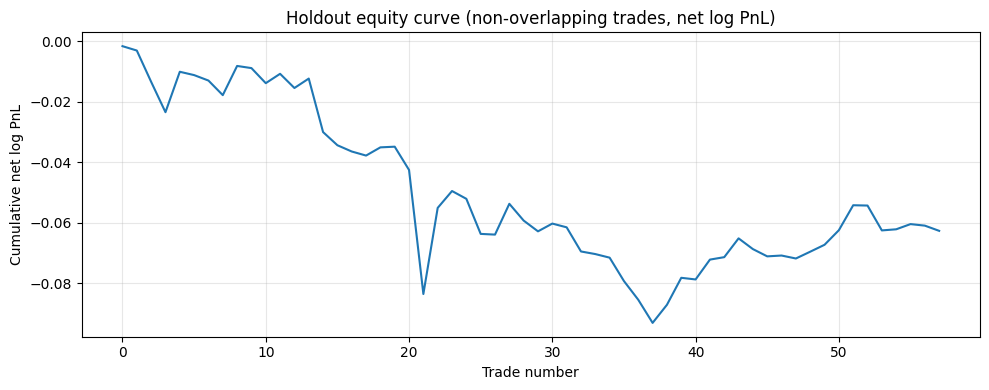

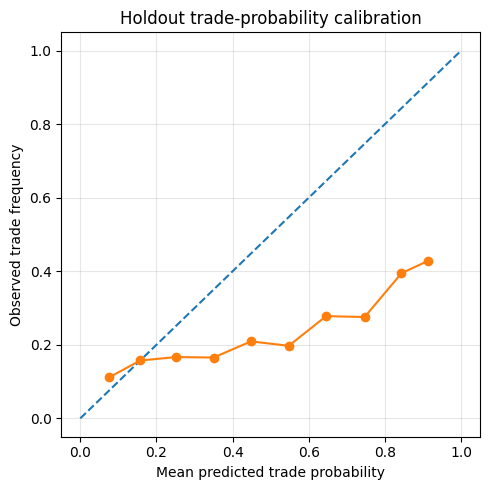

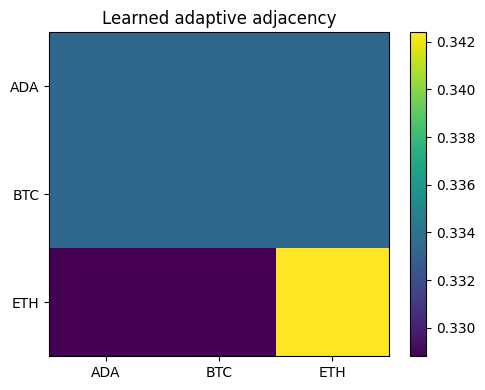

In [28]:
# Optional plots / diagnostics
# This cell draws a few useful diagnostics for the final production-holdout run.

if any([CFG["plot_equity_curve"], CFG["plot_trade_calibration"], CFG["plot_adaptive_adjacency"]]):
    import matplotlib.pyplot as plt

if bool(CFG["plot_equity_curve"]):
    eq = production_artifact["test_eval"]["equity_curve"]
    if len(eq) > 0:
        plt.figure(figsize=(10, 4))
        plt.plot(eq)
        plt.title("Holdout equity curve (non-overlapping trades, net log PnL)")
        plt.xlabel("Trade number")
        plt.ylabel("Cumulative net log PnL")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if bool(CFG["plot_trade_calibration"]):
    p_trade = production_artifact["test_pred"]["p_trade"]
    y_trade_true = production_artifact["test_pred"]["y_trade_true"]
    bins = np.linspace(0.0, 1.0, 11)
    bin_ids = np.digitize(p_trade, bins) - 1

    xs, ys = [], []
    for b in range(len(bins) - 1):
        mask = bin_ids == b
        if mask.sum() < 5:
            continue
        xs.append(float(p_trade[mask].mean()))
        ys.append(float(y_trade_true[mask].mean()))

    if xs:
        plt.figure(figsize=(5, 5))
        plt.plot([0, 1], [0, 1], "--")
        plt.plot(xs, ys, marker="o")
        plt.title("Holdout trade-probability calibration")
        plt.xlabel("Mean predicted trade probability")
        plt.ylabel("Observed trade frequency")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if bool(CFG["plot_adaptive_adjacency"]):
    # Rebuild the final model and inspect its adaptive adjacency matrix.
    model = GraphWaveNetBaseline(
        node_dim=X_NODE_RAW.shape[-1],
        edge_dim=EDGE_FEATURE_RAW.shape[-1],
        n_nodes=len(ASSETS),
        target_node=TARGET_NODE,
        cfg=CFG,
    ).to(DEVICE)
    model.load_state_dict(production_artifact["model_state"])
    model.eval()

    with torch.no_grad():
        a_adapt, _ = model.adaptive_adj()
        a_adapt_np = a_adapt.detach().cpu().numpy()

    plt.figure(figsize=(5, 4))
    plt.imshow(a_adapt_np, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(ASSETS)), ASSETS)
    plt.yticks(range(len(ASSETS)), ASSETS)
    plt.title("Learned adaptive adjacency")
    plt.tight_layout()
    plt.show()


In [29]:
# Final printed sanity checks
# This cell prints the key leakage-safe and thesis-relevant checks at the end.

print("\n" + "=" * 100)
print("FINAL SANITY CHECKS")
print(f"Frequency: {CFG['freq']} | bar={DERIVED['bar_timedelta']}")
print(f"Forecast horizon: {HORIZON_BARS} bars = {CFG['forecast_horizon_minutes']} minutes")
print(f"Lookback: {LOOKBACK_BARS} bars = {CFG['lookback_minutes']} minutes")
print(f"Receptive field: {DERIVED['receptive_field_bars']} bars")
print(f"Panel rows: {len(panel)}")
print(f"Usable samples: {len(ENTRY_INDICES)}")
print(f"Final holdout samples: {len(IDX_HOLDOUT)}")
print(f"Trade label ratio (all usable samples): {np.mean(TARGETS['y_trade'][ENTRY_INDICES]):.4f}")
print(
    f"Production holdout trades: {production_artifact['test_eval']['n_trades']} | "
    f"trade_rate={production_artifact['test_eval']['trade_rate']:.4f}"
)
print(
    f"Production holdout costs: spread-crossing via midpoint±spread/2, "
    f"fee={CFG['fee_bps_one_way']} bps one-way"
)
print(f"Artifacts saved in: {ART_DIR.resolve()}")


FINAL SANITY CHECKS
Frequency: 1min | bar=0 days 00:01:00
Forecast horizon: 5 bars = 5 minutes
Lookback: 60 bars = 60 minutes
Receptive field: 31 bars
Panel rows: 17104
Usable samples: 17039
Final holdout samples: 2556
Trade label ratio (all usable samples): 0.1980
Production holdout trades: 58 | trade_rate=0.0227
Production holdout costs: spread-crossing via midpoint±spread/2, fee=1.0 bps one-way
Artifacts saved in: /Users/vitalii/Desktop/Model_Market_Microstructure/Graph_Neural_Network_for_Market_Microstructure/TGNN2026/artifacts_baseline_fixed5m
